In [1]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_02_daily_state_sales_artifact.pkl
level_03_daily_cat_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_05_daily_state_cat_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl


In [5]:
ARTIFACT = "level_03_daily_cat_sales_artifact"

In [6]:
import joblib
from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-09-04 19:03:53.439 | INFO     | src.data.split:load_data:359 - level_03_daily_cat | target=sales | 5,823 filas | 191 features (9 categóricas)
2026-09-04 19:03:53.459 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 5,655 rows)
2026-09-04 19:03:53.462 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 84 rows)
2026-09-04 19:03:53.465 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 84 rows)
2026-09-04 19:03:53.882 | INFO     | src.data.split:split_data:421 - Features: 183 (9 categóricas)


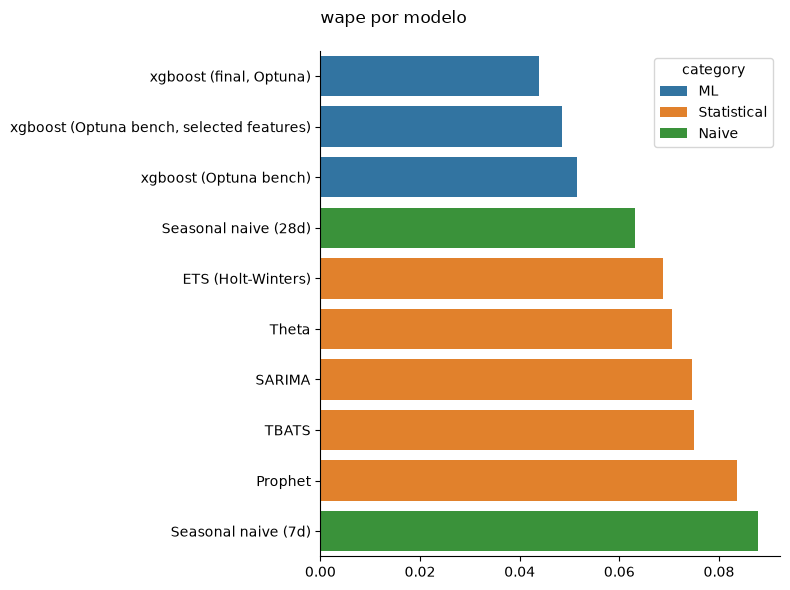

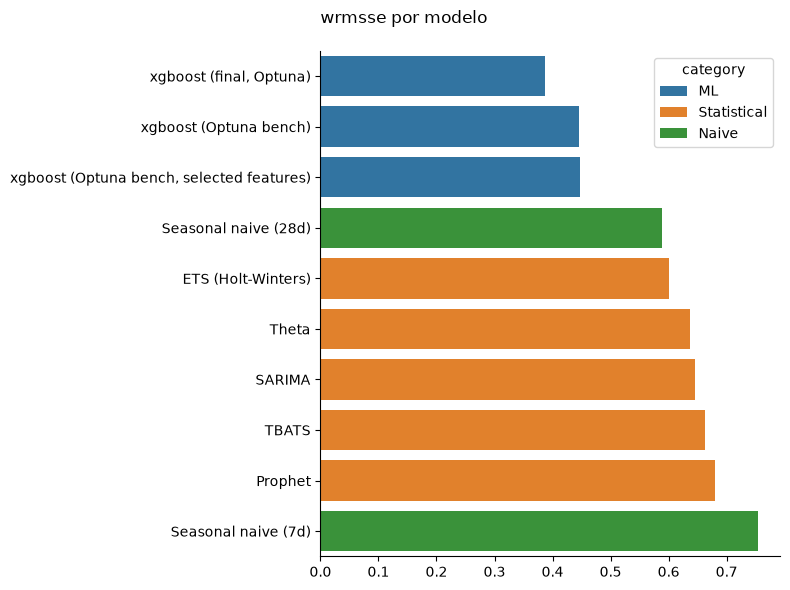

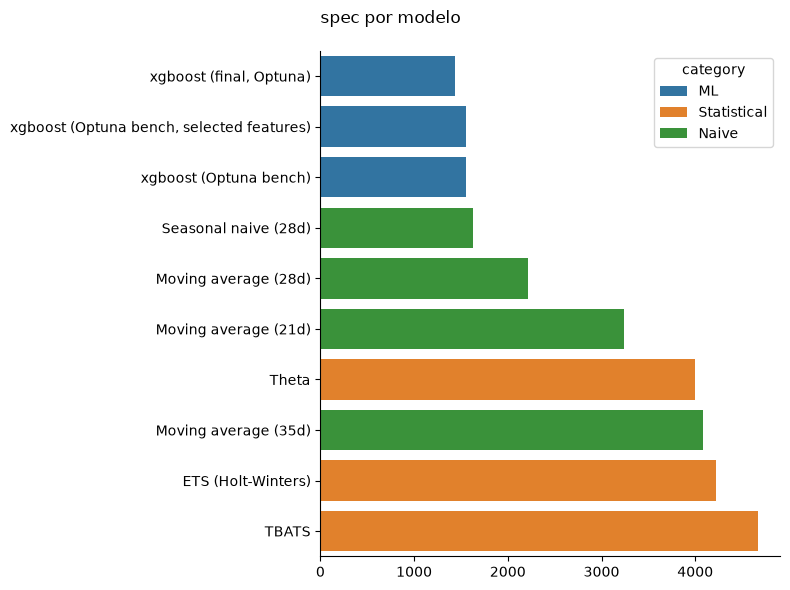

In [7]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df.nsmallest(10, col), hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [8]:
import shap

explainer = artifact["explainer"]

X_shap = model.prepare(X_test.sample(n=min(300_000, len(X_test)), random_state=42))

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

               feature  mean_abs_shap
2               cat_id    6220.214355
51     te_weekend_mean    1930.625610
82               lag28     812.901611
60                lag1     235.906418
65                lag7     198.165558
..                 ...            ...
8         event_type_2       0.000000
14         has_event_2       0.000000
7         event_name_2       0.000000
55         pct_zero_28       0.000000
59  is_likely_stockout       0.000000

[183 rows x 2 columns]


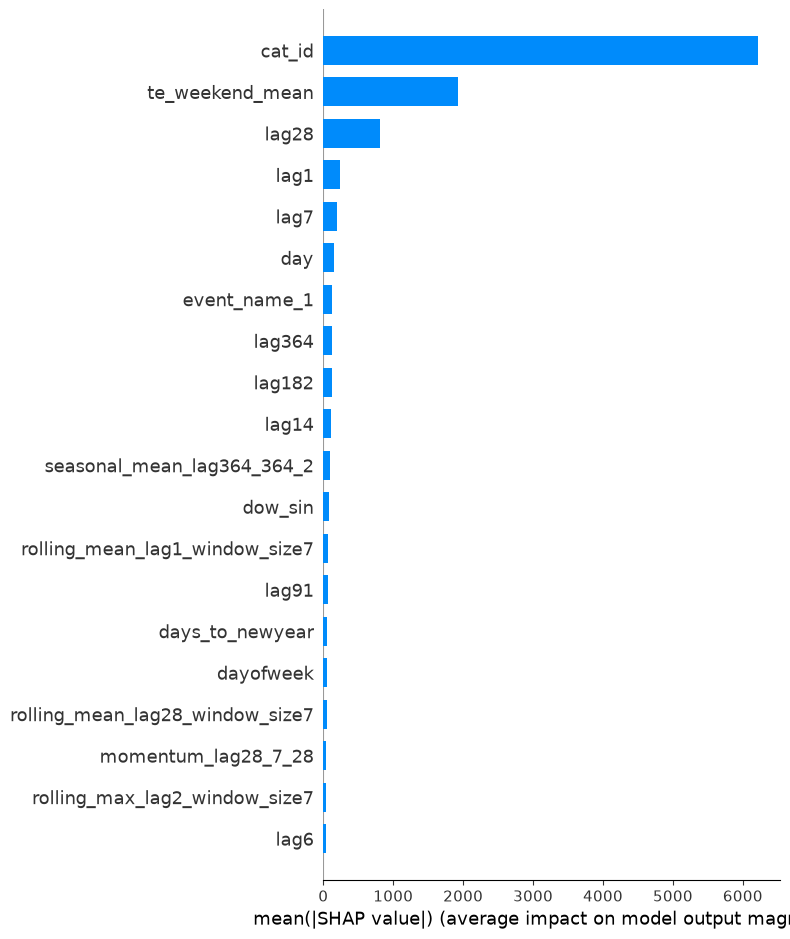

In [9]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [10]:
#shap.summary_plot(shap_values, X_shap)

# Predicciones

In [11]:
from src.evaluation import analizar_prediccion, plot_forecast

In [12]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,170,632
Diff: -61,132
Test WAPE: 5.7%
Test BIAS: -5.0%
Test WRMSSE: 0.494


In [ ]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS,28,28,832488.0,783316.0,49172.0,52090.0,2235403.25,0.573037,0.062571,-0.059066,0.075952,26.431484,0.629602,0.631491,19005.616071
HOUSEHOLD,28,28,283420.0,275646.0,7774.0,11998.0,1162333.75,0.297960,0.042333,-0.027429,0.054337,18.142357,0.353327,0.398596,1641.232143
HOBBIES,28,28,115856.0,111670.0,4186.0,5806.0,503239.00,0.129003,0.050114,-0.036131,0.058966,20.187392,0.445400,0.485494,1599.830357


In [ ]:
df_metrics.sort_values('wape').round(4)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOUSEHOLD,28,28,283420.0,275646.0,7774.0,11998.0,1162333.75,0.298,0.0423,-0.0274,0.0543,18.1424,0.3533,0.3986,1641.2321
HOBBIES,28,28,115856.0,111670.0,4186.0,5806.0,503239.00,0.129,0.0501,-0.0361,0.0590,20.1874,0.4454,0.4855,1599.8304
FOODS,28,28,832488.0,783316.0,49172.0,52090.0,2235403.25,0.573,0.0626,-0.0591,0.0760,26.4315,0.6296,0.6315,19005.6161


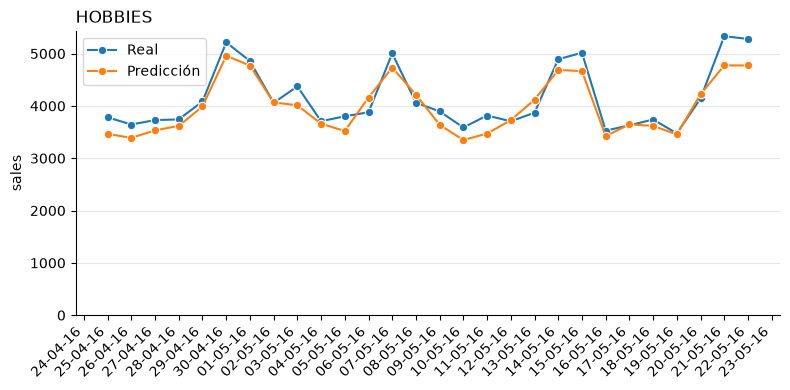

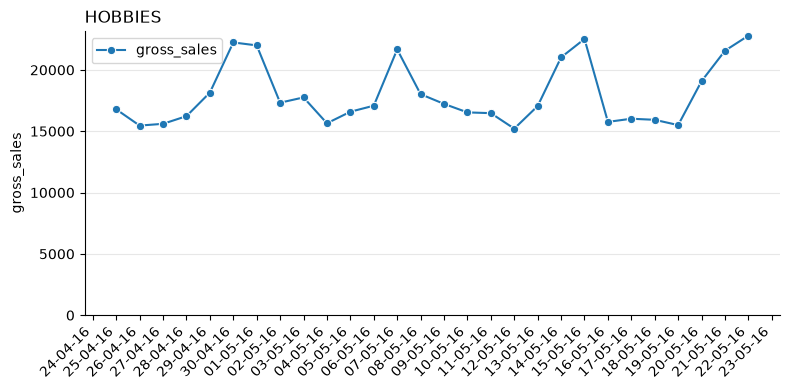

In [15]:
SERIES = 'HOBBIES'
df_sample = df_pred.query(f'series_id == "{SERIES}"').copy()

#display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)
plot_forecast(df_pred, 'gross_sales', series_id=SERIES)
#plot_forecast(df_pred, 'wape', series_id=SERIES)
#plot_forecast(df_pred, 'bias', series_id=SERIES)

In [ ]:
for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

In [ ]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)